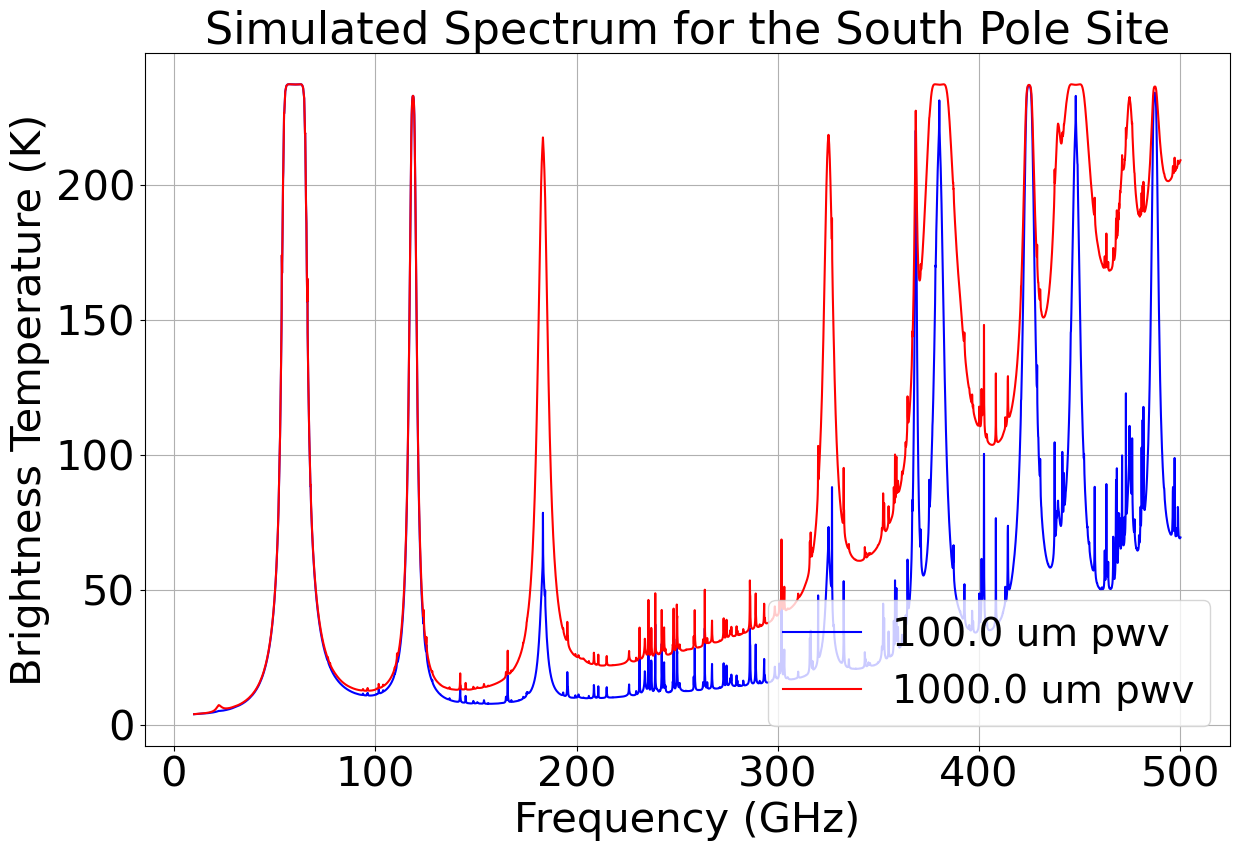

In [2]:
from typing import Dict
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
import os

name = "0.1_1pwv"
#load the data  
output_file = f"{name}_inp_SP.txt"
output_data = np.loadtxt(output_file)
#print(output_data)
#seperate the rows by PWV
out_dict: Dict[str, Dict[str,list]] = {}
for row in output_data:

    if row[1] == 0:
        pwv = np.round(row[0], 1)
        key = f"{pwv*1000} {u.micrometer} pwv"
        out_dict[key] = {}

    elif row[1] != 0:
        #add the frequency and brightness temperature to the dictionary
        #key = f"{row[0]:.2f}mm pwv"
        if "frequencies" not in out_dict[key]:
            out_dict[key]["frequencies"] = []
            out_dict[key]["brightness_temperature"] = []
            out_dict[key]["opacity"] = []
        out_dict[key]["frequencies"].append(row[0])
        out_dict[key]["brightness_temperature"].append(row[1])
        out_dict[key]["opacity"].append(row[2])

        
#print(out_dict)

# fre = output_data[:, 0] * u.GHz
# Tb = output_data[:, 1] * u.K

colors = ['blue', 'red']


fig0,ax0 = plt.subplots(figsize=(28/2, 18/2))
#fig1,ax1 = plt.subplots(figsize=(16, 9))

for key in out_dict:
    fre = np.array(out_dict[key]["frequencies"]) * u.GHz
    Tb = np.array(out_dict[key]["brightness_temperature"]) * u.K
    opa = np.array(out_dict[key]["opacity"]) * u.one

    #plot the data
    ax0.plot(fre.value, Tb.value, label=f"{key}", color=colors.pop(0))
    ax0.set_xlabel('Frequency (GHz)',fontsize=30)
    ax0.set_ylabel('Brightness Temperature (K)',fontsize=30)
    ax0.tick_params(axis='y', labelsize=30)
    ax0.tick_params(axis='x', labelsize=30)
    ax0.set_title('Simulated Spectrum for the South Pole Site',fontsize=32)
    ax0.grid(True)
    ax0.legend(loc='lower right', fontsize=28)

name = "0.1_1pwv_1006"

fig0.savefig(f"results/{name}_Tb1006.png",dpi = 500)
fig0.savefig(f"results/{name}_Tb1006.svg")

plt.show()
